In [1]:
import pandas as pd

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = temp_res.index.copy()

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res = price_resid["price_deseasoned"].copy()
time_price = price_res.index.copy()

In [ ]:
import numpy as np
import pandas as pd
from scipy.linalg import expm


temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)

temp_res = temp_resid["temp_deseasoned"].copy()

time_temp = pd.to_datetime(temp_res.index)

y = temp_res.to_numpy(dtype=float)

t = np.arange(len(y), dtype=float)

#CARMA parameters 

a1 = 0.93
a2 = 0.02515
b0 = 1.786
b1 = 1
sigma2 = 0.3611
sigma = np.sqrt(sigma2)

yerr = np.full_like(y, 1e-6, dtype=float)

def van_loan_discretization(A, G, dt):
    n = A.shape[0]

    M = np.block([
        [A, G @ G.T],
        [np.zeros((n, n)), -A.T]
    ]) * dt

    E = expm(M)

    F = E[:n, :n]
    Q = E[:n, n:] @ F.T
    return F, Q

#kalman filter for carma(2,1)

def kalman_filter_carma21(t, y, a1, a2, b0, b1, sigma, yerr=None,
                          x0=None, P0=None, jitter=1e-10):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if yerr is None:
        yerr = np.full_like(y, 1e-6, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)

    if not np.all(np.diff(t) > 0):
        raise ValueError("time must be i")

    n = len(y)
    m = 2

    # Modèle continu
    A = np.array([
        [0.0, 1.0],
        [-a2, -a1]
    ], dtype=float)

    L = np.array([
        [0.0],
        [sigma]
    ], dtype=float)

    H = np.array([[b0, b1]], dtype=float)

    if x0 is None:
        x0 = np.zeros(m)
    else:
        x0 = np.asarray(x0, dtype=float)

    if P0 is None:
        P0 = np.eye(m) * 1000.0
    else:
        P0 = np.asarray(P0, dtype=float)

    x_pred = np.zeros((n, m))
    P_pred = np.zeros((n, m, m))
    x_filt = np.zeros((n, m))
    P_filt = np.zeros((n, m, m))
    y_pred = np.zeros(n)
    resid = np.zeros(n)
    std_resid = np.zeros(n)
    S_all = np.zeros(n)

    loglik = 0.0

    x_prev = x0.copy()
    P_prev = P0.copy()

    for k in range(n):
        # Prediction
        if k == 0:
            xk_pred = x_prev
            Pk_pred = P_prev
        else:
            dt = t[k] - t[k - 1]
            F, Q = van_loan_discretization(A, L, dt)
            xk_pred = F @ x_prev
            Pk_pred = F @ P_prev @ F.T + Q

        # Observation
        Rk = float(yerr[k] ** 2 + jitter)

        mu_k = float(H @ xk_pred)
        Sk = float(H @ Pk_pred @ H.T + Rk)

        vk = y[k] - mu_k

        Kk = (Pk_pred @ H.T) / Sk

        xk_filt = xk_pred + Kk[:, 0] * vk
        Pk_filt = Pk_pred - Kk @ H @ Pk_pred

        x_pred[k] = xk_pred
        P_pred[k] = Pk_pred
        x_filt[k] = xk_filt
        P_filt[k] = Pk_filt
        y_pred[k] = mu_k
        resid[k] = vk
        std_resid[k] = vk / np.sqrt(Sk)
        S_all[k] = Sk

        loglik += -0.5 * (np.log(2 * np.pi) + np.log(Sk) + (vk ** 2) / Sk)

        x_prev = xk_filt
        P_prev = Pk_filt

    return {
        "A": A,
        "L": L,
        "H": H,
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "y_pred": y_pred,
        "resid": resid,
        "std_resid": std_resid,
        "S": S_all,
        "loglik": loglik,
    }

res = kalman_filter_carma21(
    t=t,
    y=y,
    a1=a1,
    a2=a2,
    b0=b0,
    b1=b1,
    sigma=sigma,
    yerr=yerr
)

y_hat = res["y_pred"]
innov = res["resid"]
z = res["std_resid"]
loglik = res["loglik"]

print("Log-likelihood :", loglik)
print("eigenvalues of A :", np.linalg.eigvals(res["A"]))

rmse = np.sqrt(np.mean((y - y_hat) ** 2))
mae = np.mean(np.abs(y - y_hat))

print("RMSE :", rmse)
print("MAE  :", mae)

C:\Users\gabri\AppData\Local\Temp\ipykernel_22424\2097121425.py:112: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu_k = float(H @ xk_pred)
C:\Users\gabri\AppData\Local\Temp\ipykernel_22424\2097121425.py:113: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Sk = float(H @ Pk_pred @ H.T + Rk)


Log-likelihood : -51501.41917641142
eigenvalues of A : [-0.02787874 -0.90212126]
RMSE : 0.6009174009895575
MAE  : 0.4128047925304195


        lb_stat  lb_pvalue
24  2119.527841        0.0
48  3405.541558        0.0
72  4257.854989        0.0


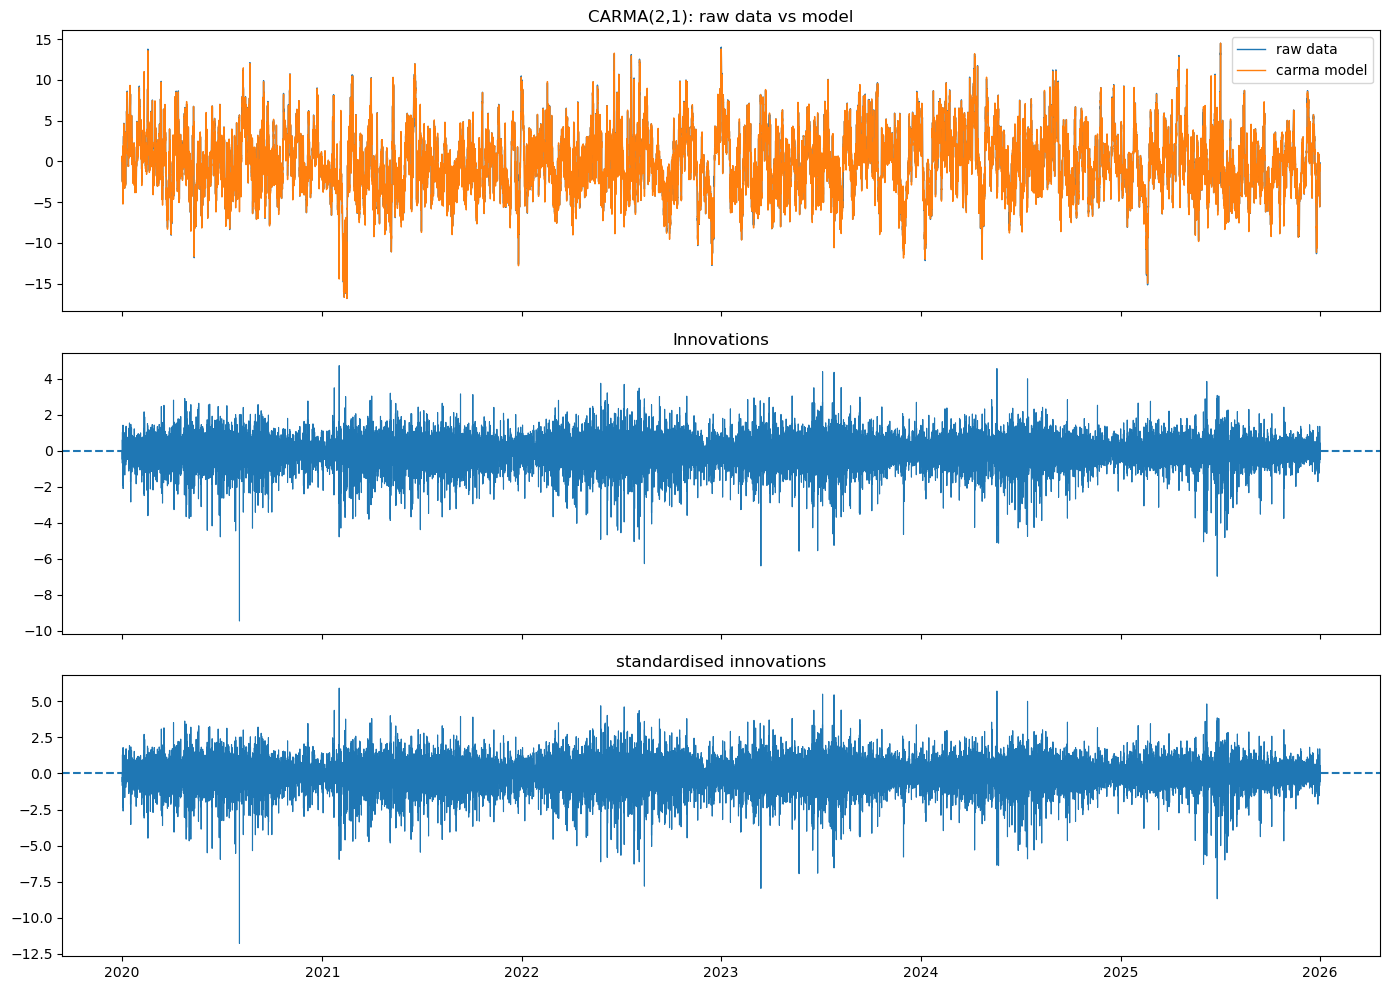

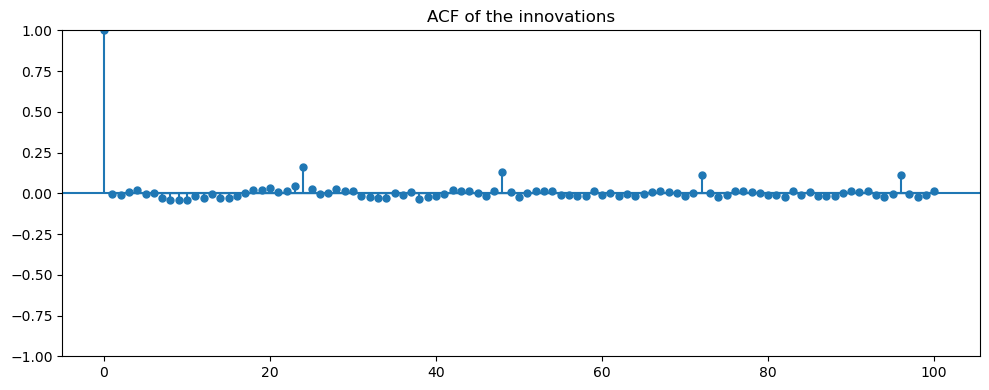

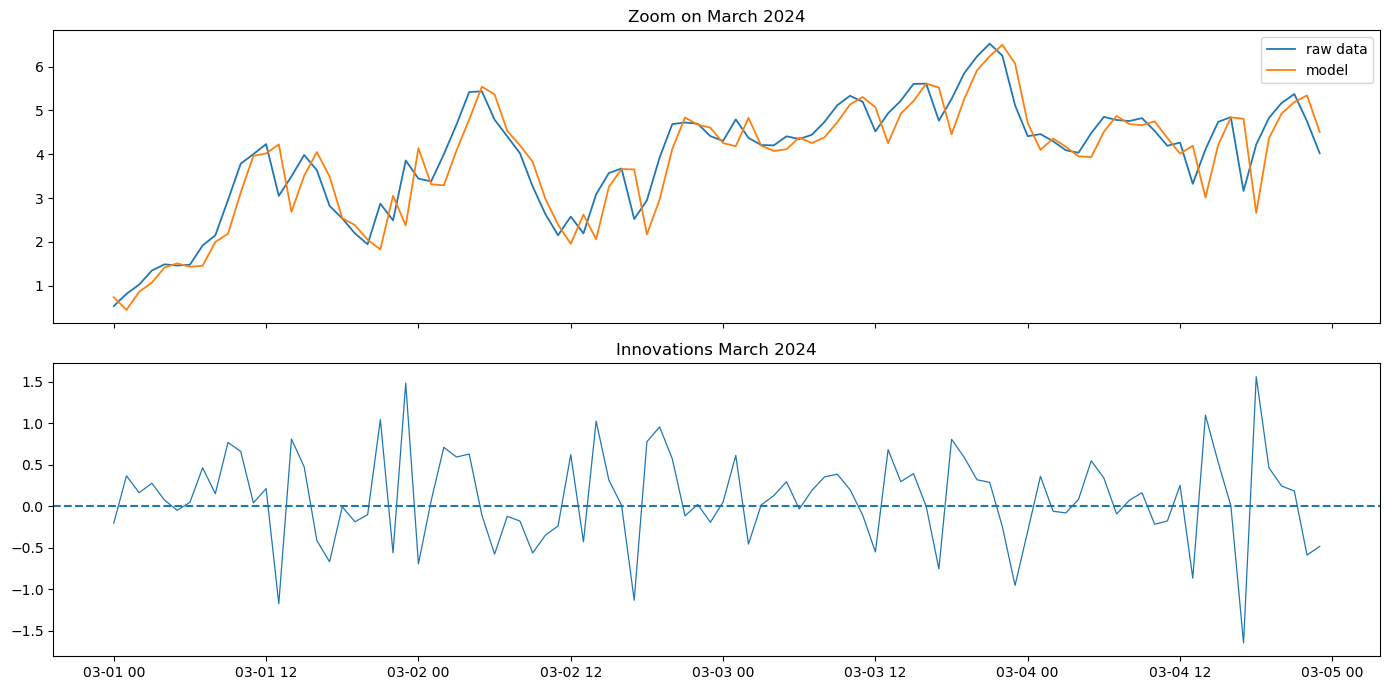

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(z, lags=[24, 48, 72], return_df=True)
print(lb)

fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(time_temp, y, label="raw data", linewidth=1)
ax[0].plot(time_temp, y_hat, label="carma model", linewidth=1)
ax[0].legend()
ax[0].set_title("CARMA(2,1): raw data vs model")

ax[1].plot(time_temp, innov, linewidth=0.8)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations")

ax[2].plot(time_temp, z, linewidth=0.8)
ax[2].axhline(0, linestyle="--")
ax[2].set_title("standardised innovations")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(z, lags=100, ax=ax)
ax.set_title("ACF of the innovations")
plt.tight_layout()
plt.show()

mask_march = (
    (time_temp >= pd.Timestamp("2024-03-01", tz="UTC")) &
    (time_temp <  pd.Timestamp("2024-03-05", tz="UTC"))
)
time_march = time_temp[mask_march]
y_march = y[mask_march]
yhat_march = y_hat[mask_march]
innov_march = innov[mask_march]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(time_march, y_march, label="raw data", linewidth=1.3)
ax[0].plot(time_march, yhat_march, label="model", linewidth=1.3)
ax[0].legend()
ax[0].set_title("Zoom on March 2024")

ax[1].plot(time_march, innov_march, linewidth=0.9)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Innovations March 2024")

plt.tight_layout()
plt.show()